<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Konwolucyjne sieci neuronowe: Zadanie

## Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-03-22 22:04:34.624178: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Zadanie

Stwórz i wytrenuj głęboką konwolucyjną sieć neuronową zdolną poprawnie sklasyfikować zdjęcia pochodzące z fragmentu bazy CIFAR-100 (25 losowych klas).

W trakcie realizacji zadania należy wykonań następujące podzadania:
1. Wygenerować dane uczące i testowe (gotowy kod).
2. Zdefiniować model głebokiej konwolucyjnej sieci neuronowej według własnego pomysłu.
3. Wytrenować zdefiniowaną sieć na danych uczących z wyodrębnieniem zbioru walidacyjnego. W procesie uczenia wykorzystać powielanie danych uczących (data augmentation, https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator)
4. Ocenić skuteczność modelu na danych testowych.
5. Powtarzać etapy 2-4 aż do osiągnięcia zadowalających wyników.
6. Przeanalizować działanie stworzonej sieci, zestawienie jakie błedy w jakich klasach, zwizualizować wytrenowane filtry i mapy cech.

### Baza CIFAR-100
- Każdemu przydzielony zostaje fragment bazy CIFAR-100 zawierający dane uczące i testowe obrazów pochodzących z 25 klas.
-Klasy wybierane są losowane w zależności od `nr_albumu`.

In [2]:
# podaj swoj nr albumu
nr_albumu = 143200

np.random.seed(nr_albumu)
(train_images_all, train_labels_all), (test_images_all, test_labels_all) = (
    tf.keras.datasets.cifar100.load_data()
)
my_classes = np.random.choice(range(100), size=25, replace=False)
np.random.seed()

mask = train_labels_all[:, 0] == my_classes[0]
mask2 = test_labels_all[:, 0] == my_classes[0]
train_images = train_images_all[mask]
train_labels = np.ones(shape=(mask.sum(), 1)) * 0
test_images = test_images_all[mask2]
test_labels = np.ones(shape=(mask2.sum(), 1)) * 0
for i, cl in enumerate(my_classes[1:]):
    mask = train_labels_all[:, 0] == cl
    train_images = np.concatenate((train_images, train_images_all[mask]))
    train_labels = np.concatenate(
        (train_labels, np.ones(shape=(mask.sum(), 1)) * (i + 1))
    )
    mask2 = test_labels_all[:, 0] == cl
    test_images = np.concatenate((test_images, test_images_all[mask2]))
    test_labels = np.concatenate(
        (test_labels, np.ones(shape=(mask2.sum(), 1)) * (i + 1))
    )

print("Wylosowane klasy:")
print(my_classes)
print("Odpowiadające im nowe etykiety:")
print(np.array(range(25)))

# mieszanie danych
indx = np.arange(0, train_images.shape[0], 1, dtype=np.int32)
np.random.shuffle(indx)
train_images = train_images[indx]
train_labels = train_labels[indx]
indx = np.arange(0, test_images.shape[0], 1, dtype=np.int32)
np.random.shuffle(indx)
test_images = test_images[indx]
test_labels = test_labels[indx]

# normalizacja
train_images = train_images / 255.0
train_labels = np.int64(train_labels)
test_images = test_images / 255.0
test_labels = np.int64(test_labels)
print("Wymiary danych:")
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 60s 0us/step


/home/qertal/miniconda3/envs/python312/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Wylosowane klasy:
[19 87 64 15 21 88  3 65 78 70 74 14 67 20 50 41 80 66 16 73 11  5 44 77
 63]
Odpowiadające im nowe etykiety:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Wymiary danych:
(12500, 32, 32, 3) (12500, 1) (2500, 32, 32, 3) (2500, 1)


In [3]:
from keras.layers import Conv2D, MaxPool2D, Input, Flatten, Dense
from keras.models import Model

In [4]:
def conv_model():
    x = Input(shape=(32, 32, 3))
    conv = Conv2D(128, kernel_size=3, activation="relu")(
        x
    )  # dodaj warstwę konwolucyjną
    pool = MaxPool2D(pool_size=2)(conv)
    conv = Conv2D(256, kernel_size=3, activation="relu")(pool)
    pool = MaxPool2D(pool_size=2)(conv)
    flat = Flatten()(pool)
    h = Dense(512, activation="relu")(flat)
    # h = Dense(128, activation='relu')(h)
    y = Dense(25, activation="softmax")(h)
    return Model(inputs=x, outputs=y)


model = conv_model()
model.summary()

I0000 00:00:1774213548.536431    3368 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,030,681 (19.19 MB)

 Trainable params: 5,030,681 (19.19 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

In [6]:
from keras.callbacks import ModelCheckpoint

cb = [ModelCheckpoint("model_cibar.keras", monitor="val_accuracy", save_best_only=True)]

In [8]:
BATCH_SIZE = 64
EPOCHS = 20

model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=cb,
)

Epoch 1/20


2026-03-22 22:05:52.328020: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ff46400a900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-22 22:05:52.328072: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-03-22 22:05:52.406300: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-22 22:05:52.864437: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-22 22:05:53.499752: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="_

 13/157 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0325 - loss: 3.2472

I0000 00:00:1774213555.672609    3931 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1257 - loss: 2.9844

2026-03-22 22:05:57.665567: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 22:05:57.705052: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,256,13,13]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,15,15]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1280 - loss: 2.9772

2026-03-22 22:05:59.909838: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 22:05:59.929549: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,256,13,13]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,15,15]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.1985 - loss: 2.7566 - val_accuracy: 0.2948 - val_loss: 2.4461
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3585 - loss: 2.2168 - val_accuracy: 0.3596 - val_loss: 2.1944
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4298 - loss: 1.9291 - val_accuracy: 0.3956 - val_loss: 2.0727
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5054 - loss: 1.6756 - val_accuracy: 0.4436 - val_loss: 1.9244
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5602 - loss: 1.4395 - val_accuracy: 0.4564 - val_loss: 1.8967
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6513 - loss: 1.1630 - val_accuracy: 0.4560 - val_loss: 1.9681
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7254 - loss: 0.9040 - val_accuracy: 0.4296 - val_loss: 2.2001
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7913 - loss: 0.6806 - val_accuracy: 0.45

___

In [9]:
from tensorflow import keras
from keras.utils import image_dataset_from_directory

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.shuffle(len(train_images)).batch(BATCH_SIZE)

2026-03-22 22:06:42.016055: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 307200000 exceeds 10% of free system memory.
2026-03-22 22:06:42.233256: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 307200000 exceeds 10% of free system memory.


In [11]:
from sklearn.model_selection import train_test_split

test_images, val_images, test_labels, val_labels = train_test_split(
    test_images, test_labels, random_state=42, stratify=test_labels
)

In [12]:
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(BATCH_SIZE)

In [15]:
from keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D


def conv_model():
    x = Input(shape=(32, 32, 3))

    conv = Conv2D(64, 3, padding="same", activation="relu")(x)
    conv = BatchNormalization()(conv)
    conv = Conv2D(64, 3, padding="same", activation="relu")(conv)
    conv = BatchNormalization()(conv)
    pool = MaxPool2D()(conv)

    conv = Conv2D(128, 3, padding="same", activation="relu")(pool)
    conv = BatchNormalization()(conv)
    conv = Conv2D(128, 3, padding="same", activation="relu")(conv)
    conv = BatchNormalization()(conv)
    pool = MaxPool2D()(conv)

    gap = GlobalAveragePooling2D()(pool)

    h = Dense(256, activation="relu")(gap)
    h = Dropout(0.5)(h)

    y = Dense(25, activation="softmax")(h)

    return Model(inputs=x, outputs=y)

In [16]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=cb,
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.2042 - loss: 2.7674 - val_accuracy: 0.2576 - val_loss: 2.5526
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3436 - loss: 2.2560 - val_accuracy: 0.3568 - val_loss: 2.1899
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4258 - loss: 1.9630 - val_accuracy: 0.3936 - val_loss: 2.0658
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4928 - loss: 1.7041 - val_accuracy: 0.4344 - val_loss: 1.9764
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5551 - loss: 1.4746 - val_accuracy: 0.4512 - val_loss: 1.8975
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6201 - loss: 1.2467 - val_accuracy: 0.4392 - val_loss: 2.0352
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6944 - loss: 1.0069 - val_accuracy: 0.4612 - val_loss: 1.9864
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7665 - loss: 0.7702 - val_acc

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

datagen.fit(train_images)

In [21]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(test_images, test_labels),
    callbacks=cb,
)

Epoch 1/20
 89/196 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4173 - loss: 2.5566

2026-03-22 22:12:38.318376: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 22:12:38.341686: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,256,13,13]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,128,15,15]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4261 - loss: 2.3002

2026-03-22 22:12:42.837065: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 22:12:42.854051: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,256,13,13]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,15,15]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.4439 - loss: 2.0019 - val_accuracy: 0.4501 - val_loss: 1.9409
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5150 - loss: 1.6482 - val_accuracy: 0.4832 - val_loss: 1.8634
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5465 - loss: 1.5217 - val_accuracy: 0.4779 - val_loss: 1.8482
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5722 - loss: 1.4408 - val_accuracy: 0.4955 - val_loss: 1.8017
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5850 - loss: 1.3859 - val_accuracy: 0.4971 - val_loss: 1.8351
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6000 - loss: 1.3309 - val_accuracy: 0.5109 - val_loss: 1.7797
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6118 - loss: 1.2790 - val_accuracy: 0.5061 - val_loss: 1.8137
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6302 - loss: 1.2185 - val_accuracy: 0.48

In [26]:
from keras.callbacks import ReduceLROnPlateau

lr_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-5)

In [27]:
cb = [ModelCheckpoint("model_cibar.keras", monitor="val_loss", save_best_only=True)]

In [28]:
callbacks = [*cb, lr_cb]

In [29]:
BATCH_SIZE = 32

In [31]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(test_images, test_labels),
    callbacks=callbacks,
)

Epoch 1/20


2026-03-22 22:17:50.076986: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,30,30]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 22:17:50.090917: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,256,13,13]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,15,15]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7189 - loss: 0.9029 - val_accuracy: 0.5445 - val_loss: 1.8716 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7178 - loss: 0.8918 - val_accuracy: 0.5189 - val_loss: 1.9446 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7254 - loss: 0.8733 - val_accuracy: 0.5376 - val_loss: 1.8624 - learning_rate: 0.0010
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7387 - loss: 0.8399 - val_accuracy: 0.5296 - val_loss: 1.9349 - learning_rate: 0.0010
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7462 - loss: 0.7993 - val_accuracy: 0.5216 - val_loss: 2.0463 - learning_rate: 0.0010
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7454 - loss: 0.8029 - val_accuracy: 0.5595 - val_loss: 1.8453 - learning_rate: 0.0010
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7578 - loss: 0.7711 - va

In [34]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

In [35]:
from keras.callbacks import EarlyStopping

callbacks = [
    ModelCheckpoint(
        "best_model.keras", monitor="val_accuracy", save_best_only=True, mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1
    ),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
]

In [39]:
from keras.layers import RandomFlip, RandomTranslation, RandomRotation, RandomZoom
from keras import Sequential

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(0.1, 0.1),
        RandomRotation(0.08),
        RandomZoom(0.1),
    ]
)

In [40]:
def conv_model_better_aug():
    x = Input(shape=(32, 32, 3))
    h = data_augmentation(x)

    h = Conv2D(64, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(64, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D(pool_size=2)(h)
    h = Dropout(0.25)(h)

    h = Conv2D(128, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(128, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D(pool_size=2)(h)
    h = Dropout(0.30)(h)

    h = Conv2D(256, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(256, kernel_size=3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)

    h = GlobalAveragePooling2D()(h)
    h = Dense(256, activation="relu")(h)
    h = Dropout(0.40)(h)

    y = Dense(25, activation="softmax")(h)

    return Model(inputs=x, outputs=y)

In [41]:
model = conv_model_better_aug()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

history = model.fit(
    train_images,
    train_labels,
    batch_size=64,
    epochs=40,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40


E0000 00:00:1774214618.021109    3368 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.1489 - loss: 2.8963 - val_accuracy: 0.0732 - val_loss: 3.5239 - learning_rate: 0.0010
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.2023 - loss: 2.7092 - val_accuracy: 0.0892 - val_loss: 3.3937 - learning_rate: 0.0010
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2310 - loss: 2.5908 - val_accuracy: 0.1764 - val_loss: 2.9437 - learning_rate: 0.0010
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.2593 - loss: 2.4856 - val_accuracy: 0.2180 - val_loss: 2.8774 - learning_rate: 0.0010
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.2948 - loss: 2.3880 - val_accuracy: 0.2388 - val_loss: 2.6444 - learning_rate: 0.0010
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3171 - loss: 2.2982 - val_accuracy: 0.2036 - val_loss: 3.6547 - learning_rate: 0.0010
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.3437 - loss: 2.2027 - 

In [42]:
from keras.layers import RandomContrast

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(0.1, 0.1),
        RandomRotation(0.08),
        RandomZoom(0.1),
        RandomContrast(0.1),
    ]
)


def conv_model_stronger():
    x = Input(shape=(32, 32, 3))

    h = data_augmentation(x)

    h = Conv2D(64, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(64, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.2)(h)

    h = Conv2D(128, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(128, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.3)(h)

    h = Conv2D(256, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(256, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.35)(h)

    h = Conv2D(512, 3, padding="same", use_bias=False)(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)

    h = GlobalAveragePooling2D()(h)
    h = Dense(256, activation="relu")(h)
    h = Dropout(0.4)(h)

    y = Dense(25, activation="softmax")(h)
    return Model(x, y)

In [56]:
callbacks = [
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, mode="min", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, mode="min", verbose=1
    ),
]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

In [58]:
model = conv_model_stronger()
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=80,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80


E0000 00:00:1774221425.655703    3368 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_14_1/dropout_37_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1217 - loss: 3.0629
Epoch 1: val_loss improved from None to 3.05192, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.1404 - loss: 2.9583 - val_accuracy: 0.1240 - val_loss: 3.0519 - learning_rate: 0.0010
Epoch 2/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1905 - loss: 2.7965
Epoch 2: val_loss improved from 3.05192 to 2.97811, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.1954 - loss: 2.7616 - val_accuracy: 0.1820 - val_loss: 2.9781 - learning_rate: 0.0010
Epoch 3/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2140 - loss: 2.6941
Epoch 3: val_loss improved from 2.97811 to 2.47499, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0

In [60]:
best_model = tf.keras.models.load_model("best_model.keras")
test_loss, test_acc = best_model.evaluate(test_images, test_labels, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 1.3320106267929077
Test accuracy: 0.6138666868209839


Po modyfikacji architektury sieci oraz procedury uczenia uzyskano poprawę jakości klasyfikacji względem modelu bazowego. Najlepszy model osiągnął dokładność walidacyjną 61.20%, przy wartości funkcji straty walidacyjnej 1.3235. Najlepszy rezultat uzyskano w 46. epoce, po czym dalsze uczenie nie prowadziło już do istotnej poprawy. Różnica pomiędzy dokładnością treningową i walidacyjną wskazuje na umiarkowane przeuczenie, jednak model zachowuje zadowalającą zdolność uogólniania.

In [62]:
from keras.regularizers import l2
from keras.models import Sequential
from keras.layers import RandomFlip, RandomTranslation, RandomRotation

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(0.08, 0.08),
        RandomRotation(0.05),
    ]
)

callbacks = [
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, mode="min", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, mode="min", verbose=1
    ),
]


def conv_model_better_v2():
    x = Input(shape=(32, 32, 3))
    h = data_augmentation(x)

    h = Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.2)(h)

    h = Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.3)(h)

    h = Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = tf.keras.layers.ReLU()(h)
    h = MaxPool2D()(h)
    h = Dropout(0.35)(h)

    h = GlobalAveragePooling2D()(h)
    h = Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(h)
    h = Dropout(0.4)(h)

    y = Dense(25, activation="softmax")(h)
    return Model(x, y)


model = conv_model_better_v2()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=["accuracy"],
)

In [63]:
history2 = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=80,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80


E0000 00:00:1774247911.598608    3368 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_28_1/dropout_45_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1232 - loss: 3.1737
Epoch 1: val_loss improved from None to 3.63286, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.1464 - loss: 3.0541 - val_accuracy: 0.0624 - val_loss: 3.6329 - learning_rate: 5.0000e-04
Epoch 2/80
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1887 - loss: 2.8795
Epoch 2: val_loss improved from 3.63286 to 2.80903, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.2016 - loss: 2.8380 - val_accuracy: 0.1940 - val_loss: 2.8090 - learning_rate: 5.0000e-04
Epoch 3/80
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2351 - loss: 2.7037
Epoch 3: val_loss did not improve from 2.80903
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.2410 - loss: 2.6828 - val_accuracy: 0.1608 - val_loss: 4.0435 - learning_rate: 5.

In [64]:
best_model = tf.keras.models.load_model("best_model.keras")
test_loss, test_acc = best_model.evaluate(test_images, test_labels, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 1.30592679977417
Test accuracy: 0.662933349609375


Przechodzimy na resnet

In [ ]:
import tensorflow as tf
from keras import Model, Sequential, Input
from keras.layers import (
    ReLU,
    Add,
)

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(0.08, 0.08),
        RandomRotation(0.05),
    ]
)


def residual_block(x, filters, downsample=False, dropout_rate=0.0, wd=1e-4):
    shortcut = x
    strides = 2 if downsample else 1

    h = Conv2D(
        filters,
        3,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_regularizer=l2(wd),
    )(x)
    h = BatchNormalization()(h)
    h = ReLU()(h)

    h = Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=l2(wd))(h)
    h = BatchNormalization()(h)

    if downsample or x.shape[-1] != filters:
        shortcut = Conv2D(
            filters,
            1,
            strides=strides,
            padding="same",
            use_bias=False,
            kernel_regularizer=l2(wd),
        )(shortcut)
        shortcut = BatchNormalization()(shortcut)

    h = Add()([h, shortcut])
    h = ReLU()(h)

    if dropout_rate > 0:
        h = Dropout(dropout_rate)(h)

    return h


def conv_model_resnet():
    x = Input(shape=(32, 32, 3))
    h = data_augmentation(x)

    h = Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=l2(1e-4))(h)
    h = BatchNormalization()(h)
    h = ReLU()(h)

    h = residual_block(h, 64, downsample=False, dropout_rate=0.10)
    h = residual_block(h, 64, downsample=False, dropout_rate=0.10)

    h = residual_block(h, 128, downsample=True, dropout_rate=0.15)
    h = residual_block(h, 128, downsample=False, dropout_rate=0.15)

    h = residual_block(h, 256, downsample=True, dropout_rate=0.20)
    h = residual_block(h, 256, downsample=False, dropout_rate=0.20)

    h = GlobalAveragePooling2D()(h)
    h = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(h)
    h = Dropout(0.35)(h)
    y = Dense(25, activation="softmax")(h)

    return Model(x, y)

: 

In [66]:
model = conv_model_resnet()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=["accuracy"],
)

In [67]:
callbacks = [
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, mode="min", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, mode="min", verbose=1
    ),
]

history3 = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=80,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80


E0000 00:00:1774271549.419845    3368 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_33_1/dropout_49_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1286 - loss: 3.2823
Epoch 1: val_loss improved from None to 4.01474, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.1541 - loss: 3.1423 - val_accuracy: 0.0744 - val_loss: 4.0147 - learning_rate: 5.0000e-04
Epoch 2/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2067 - loss: 2.9335
Epoch 2: val_loss improved from 4.01474 to 3.00134, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.2179 - loss: 2.8942 - val_accuracy: 0.1960 - val_loss: 3.0013 - learning_rate: 5.0000e-04
Epoch 3/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2481 - loss: 2.7681
Epoch 3: val_loss improved from 3.00134 to 2.87509, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - acc

Test loss: 1.412601113319397
Test accuracy: 0.6469333171844482


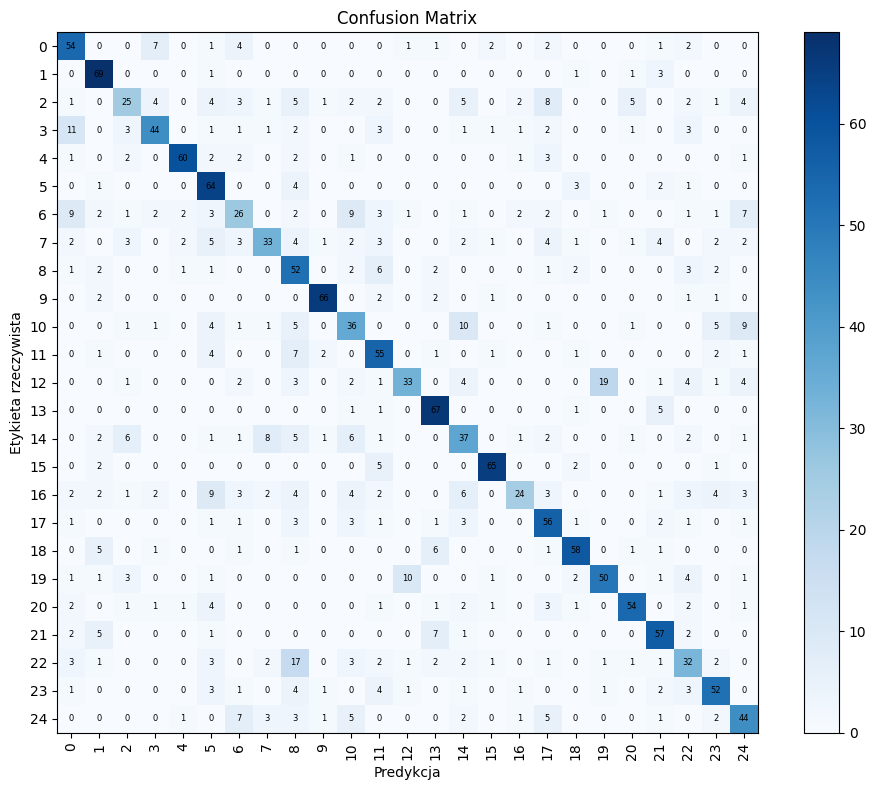

In [71]:
best_model = tf.keras.models.load_model("best_model.keras")
test_loss, test_acc = best_model.evaluate(test_images, test_labels, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Predykcje na zbiorze testowym
y_true = test_labels.ravel()
y_pred = np.argmax(best_model.predict(test_images, verbose=0), axis=1)

# Macierz pomyłek
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=25).numpy()

# Wizualizacja
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predykcja")
plt.ylabel("Etykieta rzeczywista")
plt.colorbar()

ticks = np.arange(25)
plt.xticks(ticks, ticks, rotation=90)
plt.yticks(ticks, ticks)

# ręczne adnotacje wartości
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=6)

plt.tight_layout()
plt.show()

In [93]:
def choose_image_of_class(class_idx, n_images=1, max_cols=4):
    target_class = class_idx
    labels = test_labels.flatten()
    indices = np.where(labels == target_class)[0]

    if len(indices) == 0:
        print(f"Brak obrazów dla klasy {target_class}.")
        return

    n_show = min(n_images, len(indices))
    chosen_idx = np.random.choice(indices, size=n_show, replace=False)

    imgs = test_images[chosen_idx]
    preds = model.predict(imgs, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    n_cols = min(max_cols, n_show)
    n_rows = int(np.ceil(n_show / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n_show):
        axes[i].imshow(imgs[i])
        axes[i].set_title(f"True: {labels[chosen_idx[i]]}, Pred: {pred_classes[i]}")
        axes[i].axis("off")

    for i in range(n_show, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

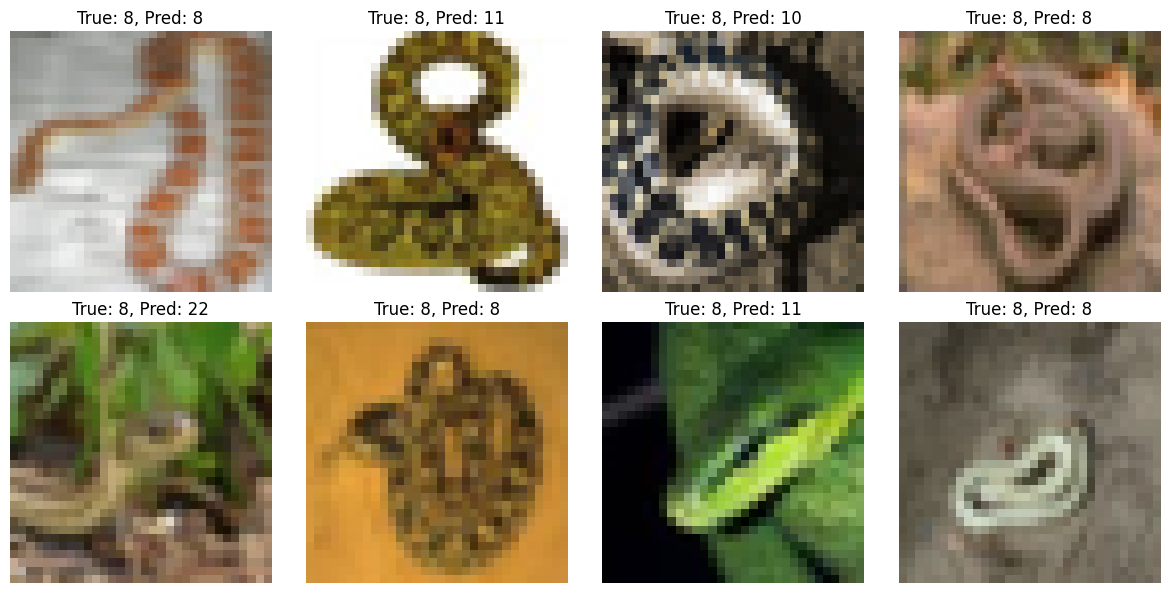

In [103]:
choose_image_of_class(8, 8)

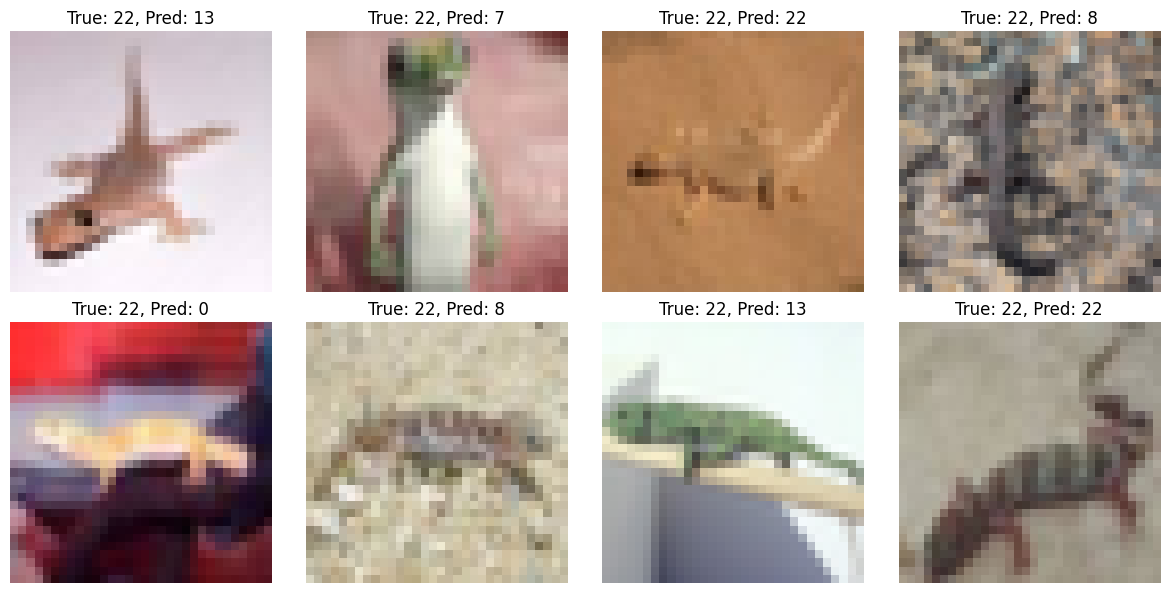

In [104]:
choose_image_of_class(22, 8)

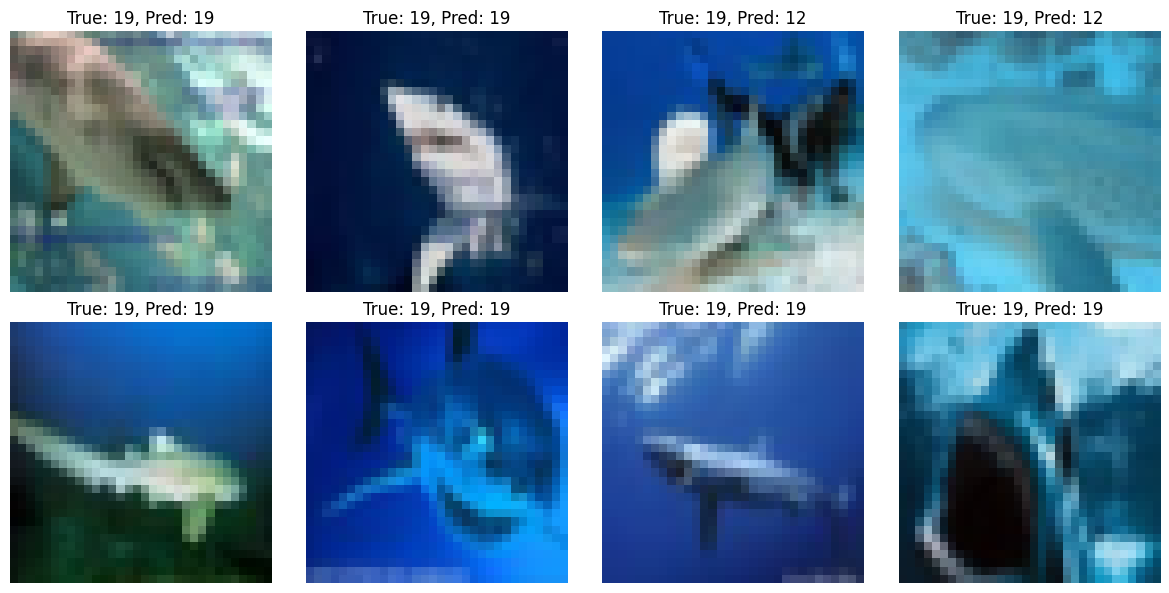

In [105]:
choose_image_of_class(19, 8)

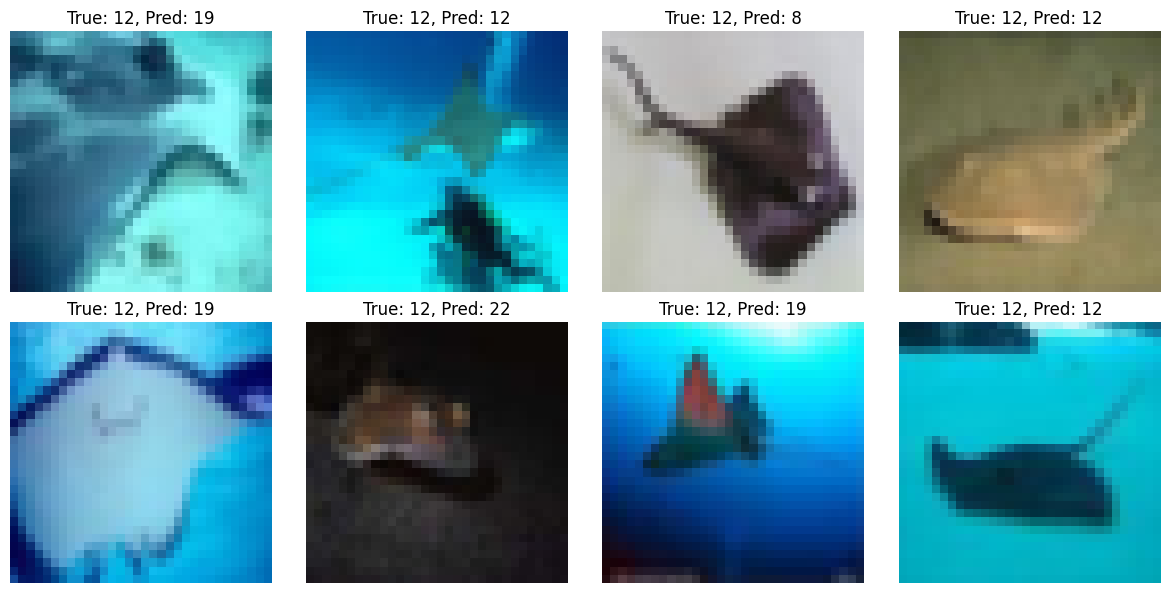

In [106]:
choose_image_of_class(12, 8)

Choć maksymalne accuracy na zbiorze testowym jakie otrzymaliśmy oscyluje wokół 65%, co nie jest najlepszym wynikiem, trzeba brać pod uwagę to, ze zbiór posiada 25 klas, co już troche poprawia humor. To co istotne najwięcej pomyłek jest pomiędzy klasami, które są do siebie "podobne". Niestety problemy takie jak niska rozdzielczość obrazów mogą mieć dość istotny wpływ przy tego typu rozgraniczeniach. To wszystko sprawia, że wynik 65% na zbiorze testowym, już nie wygląda tak źle.

Liczba warstw Conv2D: 15


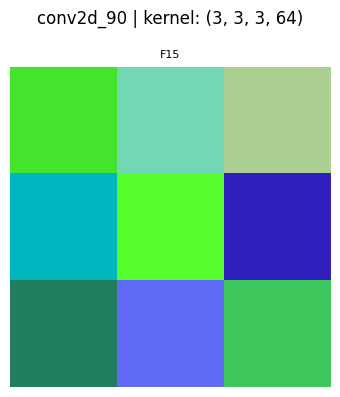

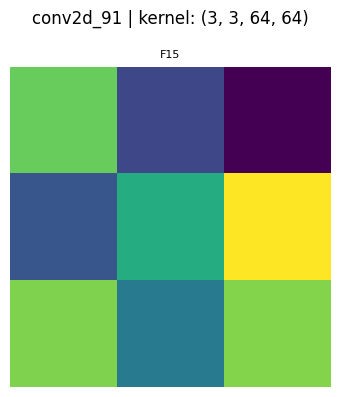

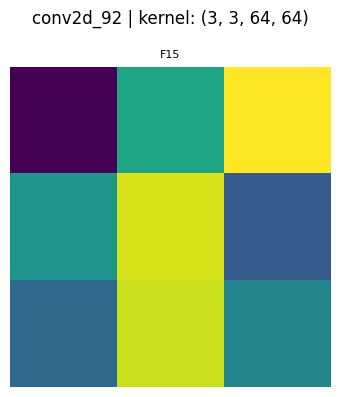

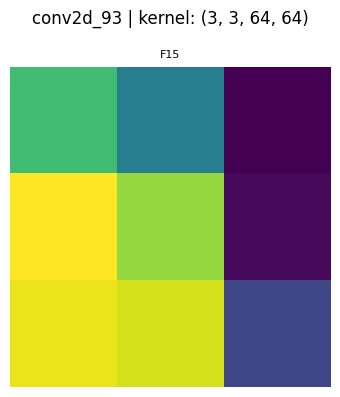

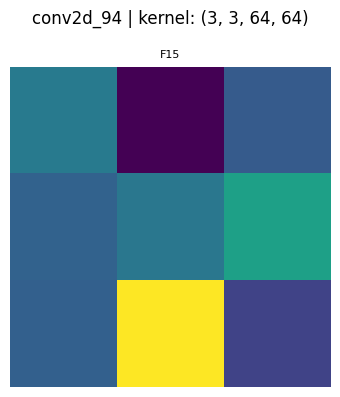

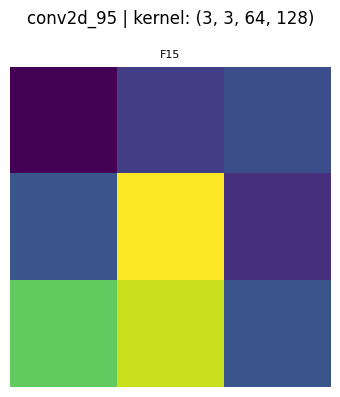

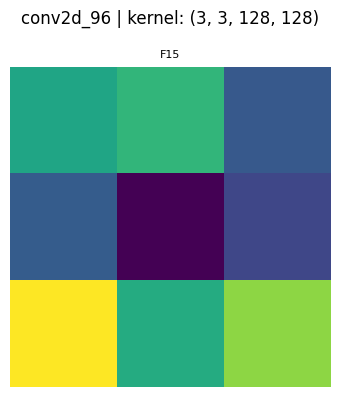

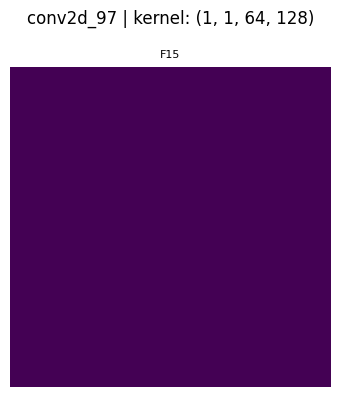

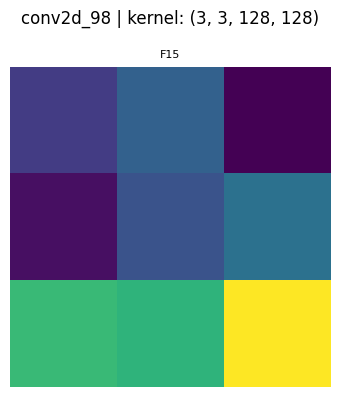

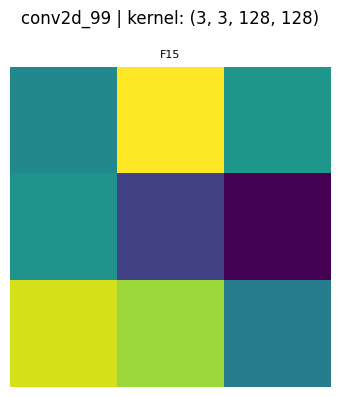

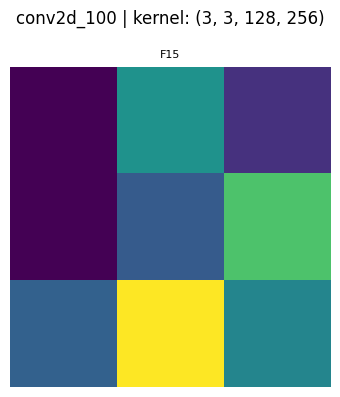

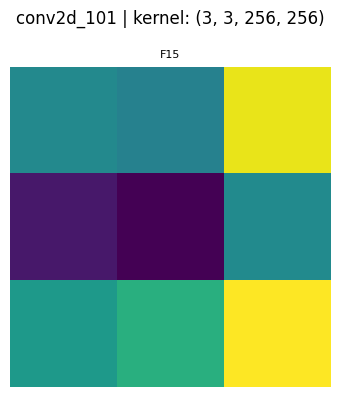

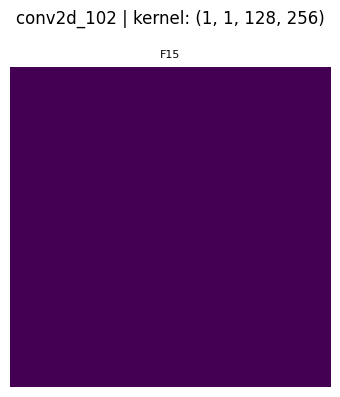

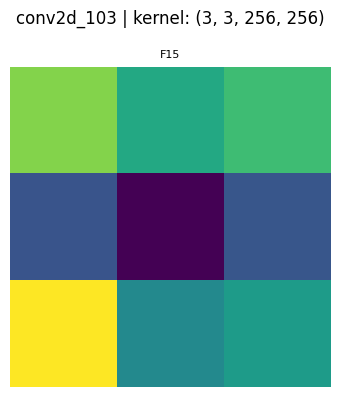

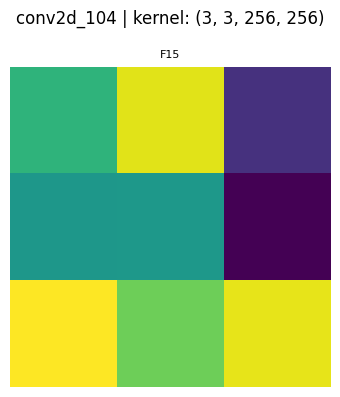

In [79]:
conv_layers = [l for l in best_model.layers if isinstance(l, tf.keras.layers.Conv2D)]
print(f"Liczba warstw Conv2D: {len(conv_layers)}")


def plot_conv_filters(layer, max_filters=16, n_cols=8):
    weights = layer.get_weights()
    if len(weights) == 0:
        print(f"{layer.name}: brak wag")
        return

    k = weights[0]
    out_ch = k.shape[-1]
    n_filters = min(max_filters, out_ch)
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(2 * n_cols, 2 * n_rows))
    for i in range(n_filters):
        f = k[:, :, :, i]

        if f.shape[-1] == 3:
            img = (f - f.min()) / (f.max() - f.min() + 1e-8)
            plt.imshow(img)
        else:
            img = np.mean(np.abs(f), axis=-1)
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            plt.imshow(img, cmap="viridis")

        plt.axis("off")
        plt.title(f"F{i}", fontsize=8)

    plt.suptitle(f"{layer.name} | kernel: {k.shape}", fontsize=12)
    plt.tight_layout()
    plt.show()


for layer in conv_layers:
    plot_conv_filters(layer, max_filters=16, n_cols=8)

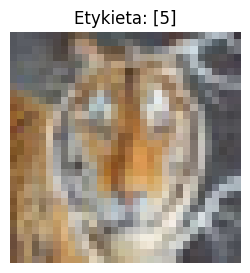

Warstwy Conv2D:
0 conv2d_90 (None, 32, 32, 64)
1 conv2d_91 (None, 32, 32, 64)
2 conv2d_92 (None, 32, 32, 64)
3 conv2d_93 (None, 32, 32, 64)
4 conv2d_94 (None, 32, 32, 64)
5 conv2d_95 (None, 16, 16, 128)
6 conv2d_96 (None, 16, 16, 128)
7 conv2d_97 (None, 16, 16, 128)
8 conv2d_98 (None, 16, 16, 128)
9 conv2d_99 (None, 16, 16, 128)
10 conv2d_100 (None, 8, 8, 256)
11 conv2d_101 (None, 8, 8, 256)
12 conv2d_102 (None, 8, 8, 256)
13 conv2d_103 (None, 8, 8, 256)
14 conv2d_104 (None, 8, 8, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [75]:
img_idx = 0
img = test_images[img_idx]
label = test_labels[img_idx]

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f"Etykieta: {label}")
plt.axis("off")
plt.show()

conv_layers = [
    layer for layer in best_model.layers if isinstance(layer, tf.keras.layers.Conv2D)
]
print("Warstwy Conv2D:")
for i, layer in enumerate(conv_layers):
    print(i, layer.name, layer.output.shape)

activation_model = tf.keras.Model(
    inputs=best_model.input, outputs=[layer.output for layer in conv_layers]
)

img_batch = np.expand_dims(img, axis=0)

feature_maps = activation_model.predict(img_batch)

In [ ]:
def plot_feature_maps(feature_map, max_maps=16, title="Mapy cech"):
    fmap = feature_map[0]
    n_maps = min(max_maps, fmap.shape[-1])

    n_cols = 4
    n_rows = int(np.ceil(n_maps / n_cols))

    plt.figure(figsize=(12, 3 * n_rows))
    for i in range(n_maps):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(fmap[:, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Mapa {i}")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

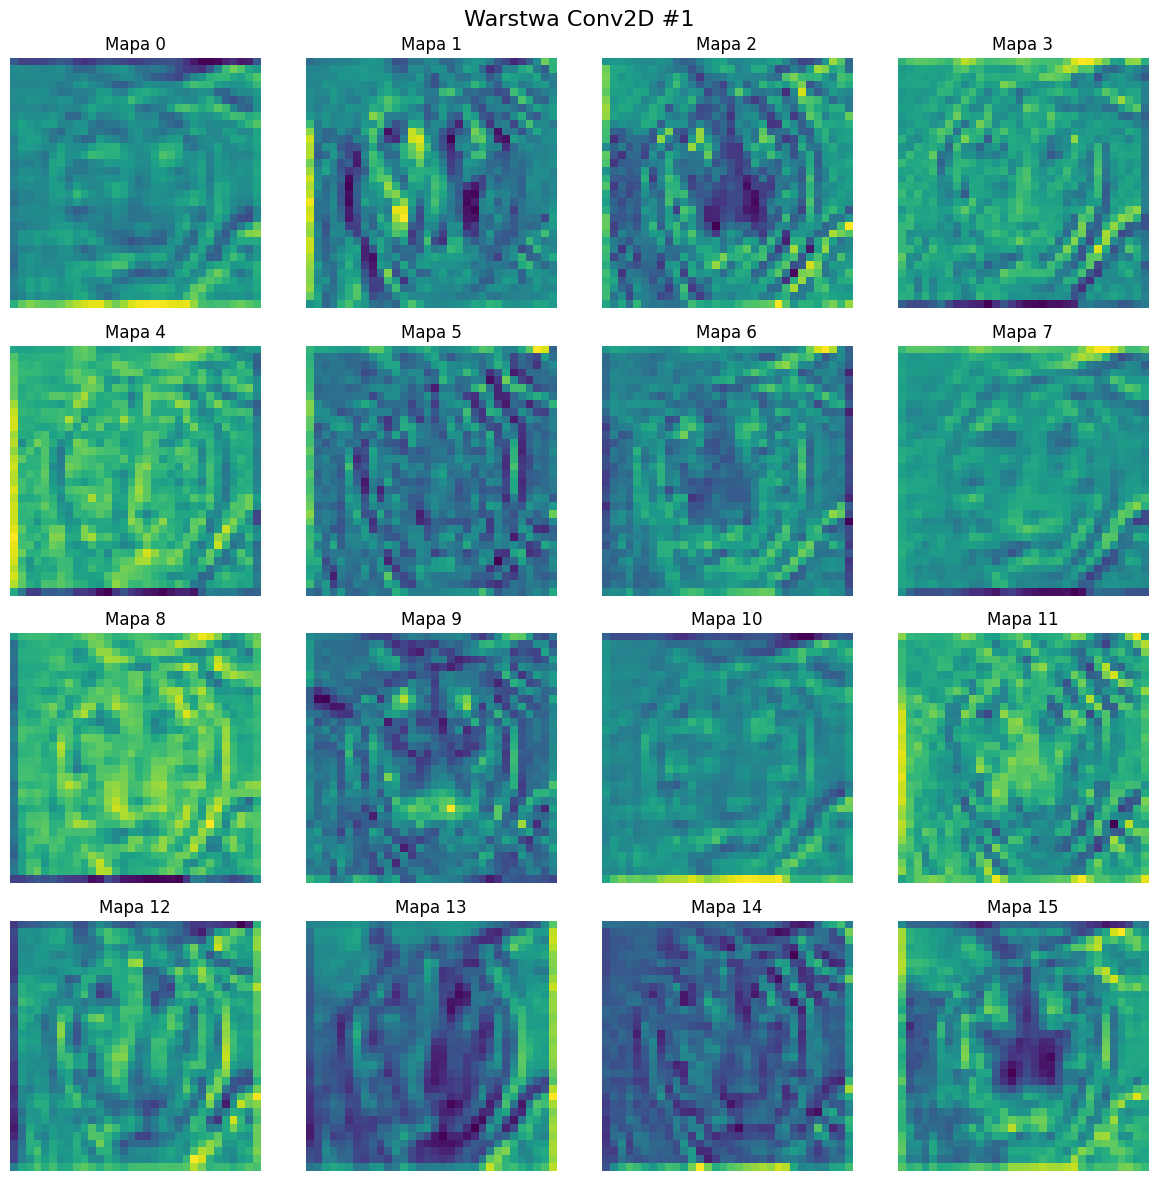

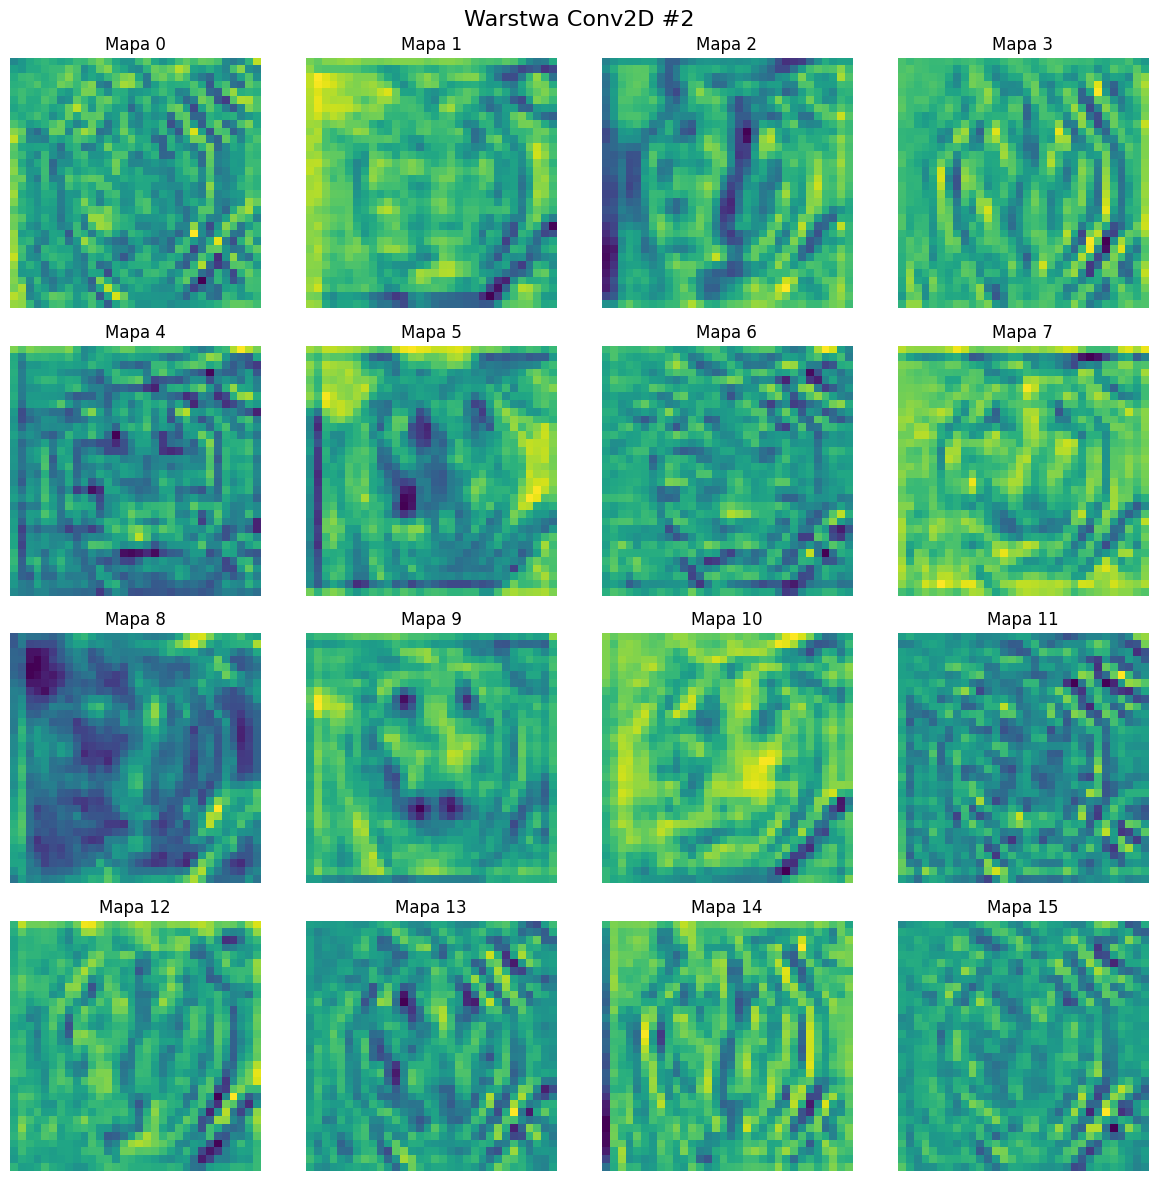

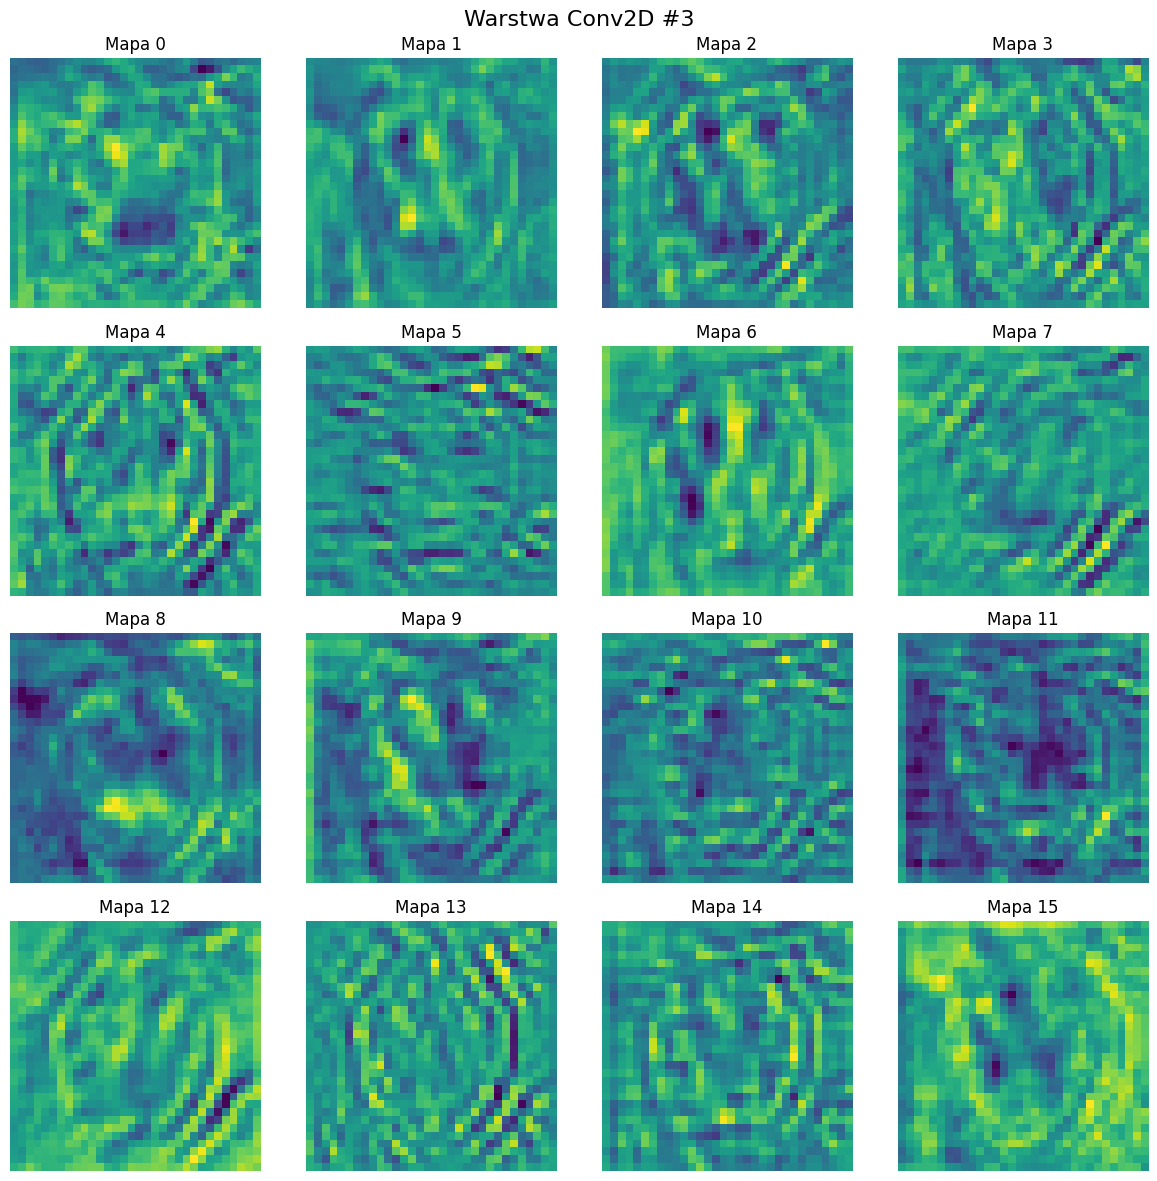

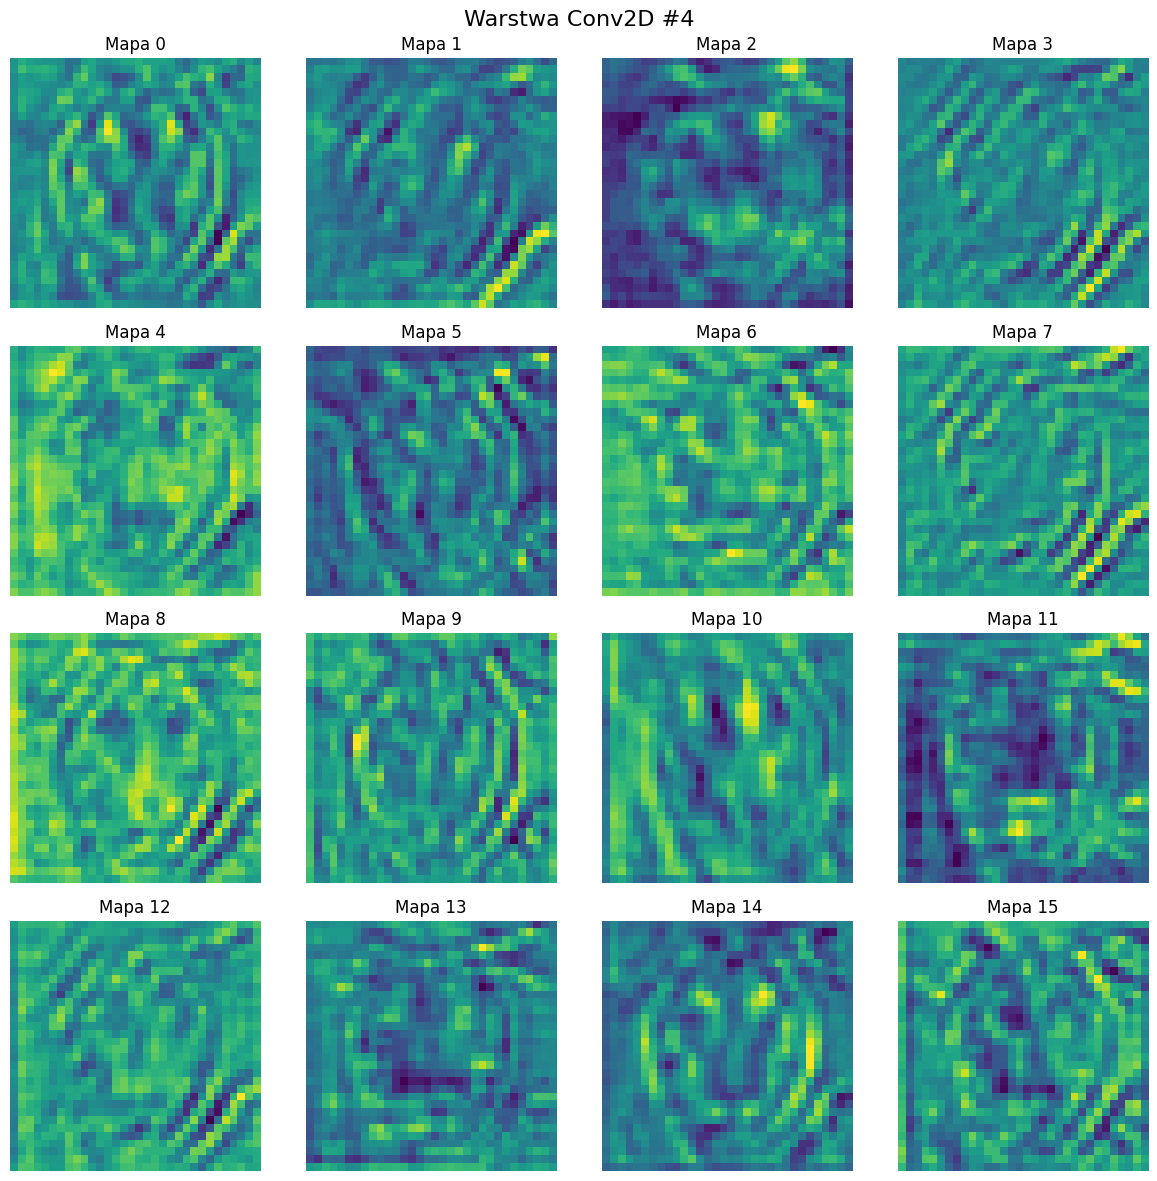

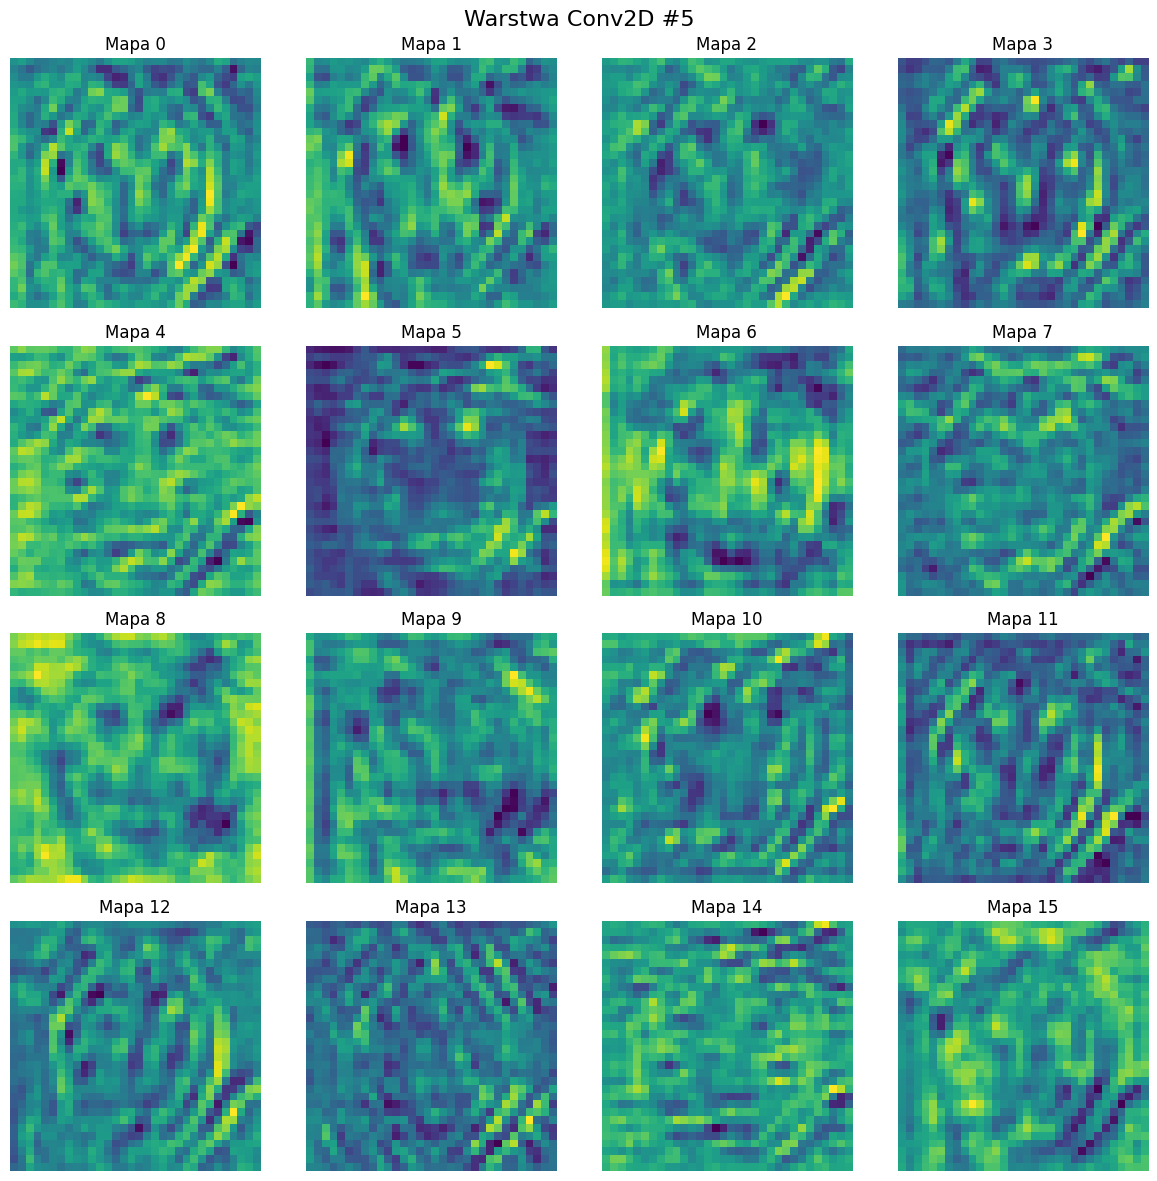

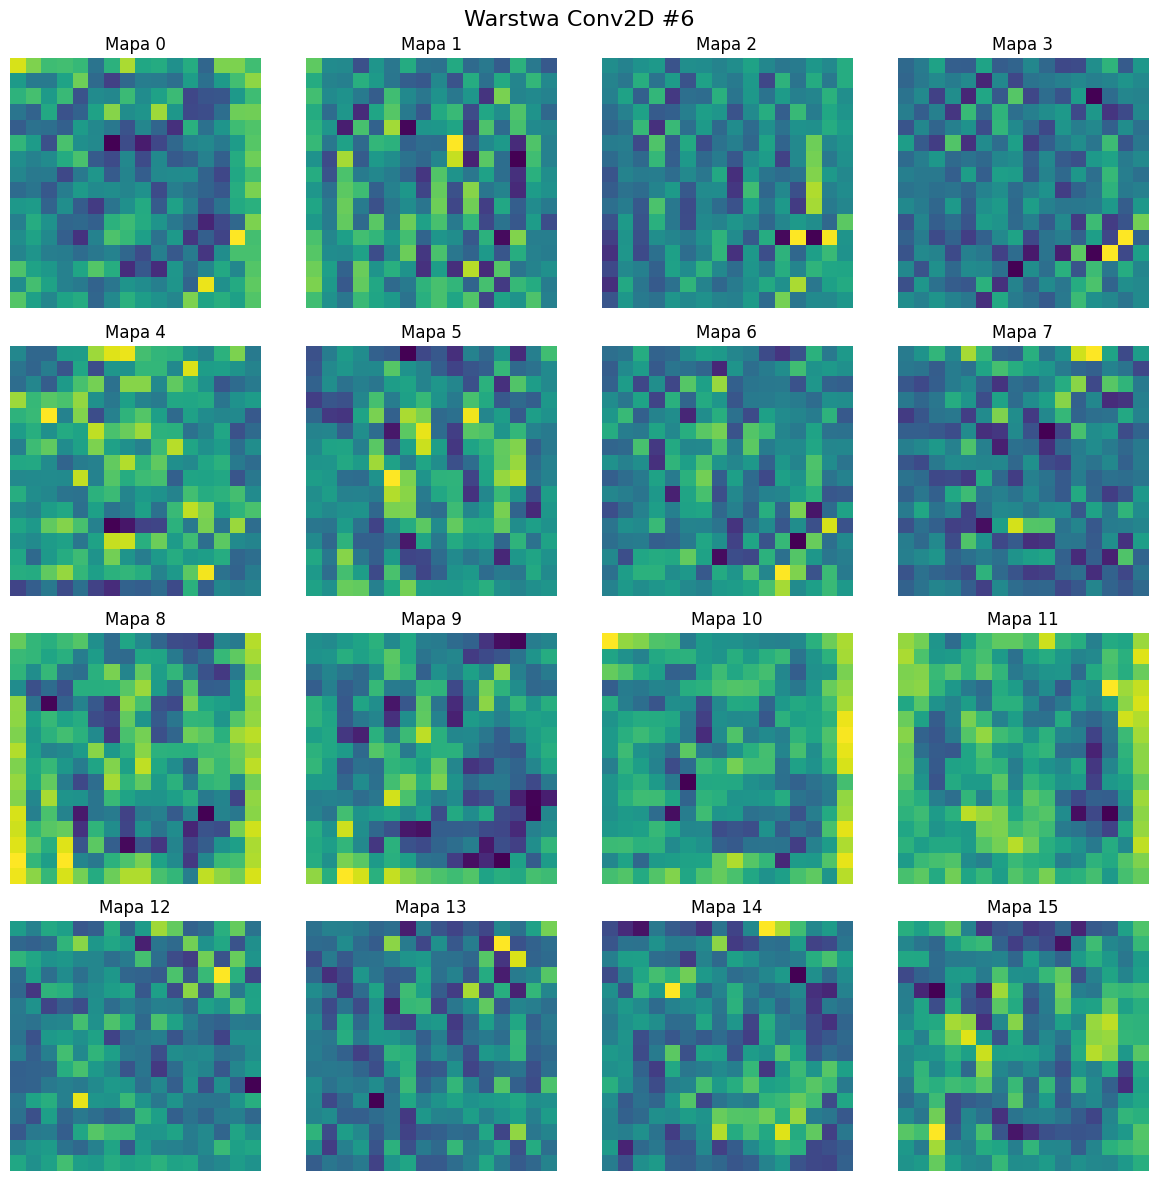

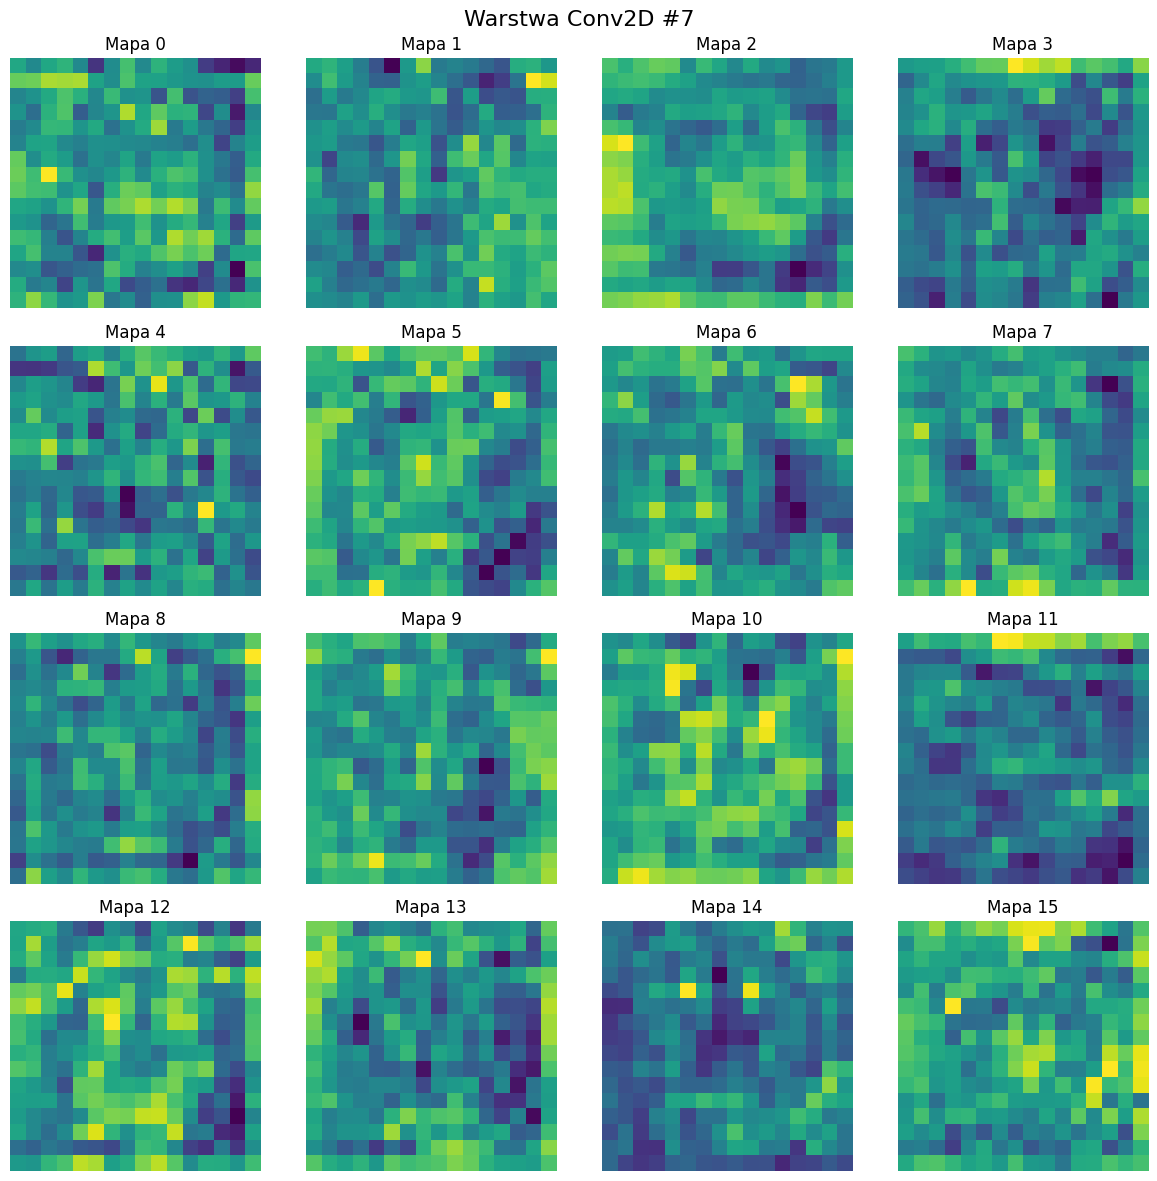

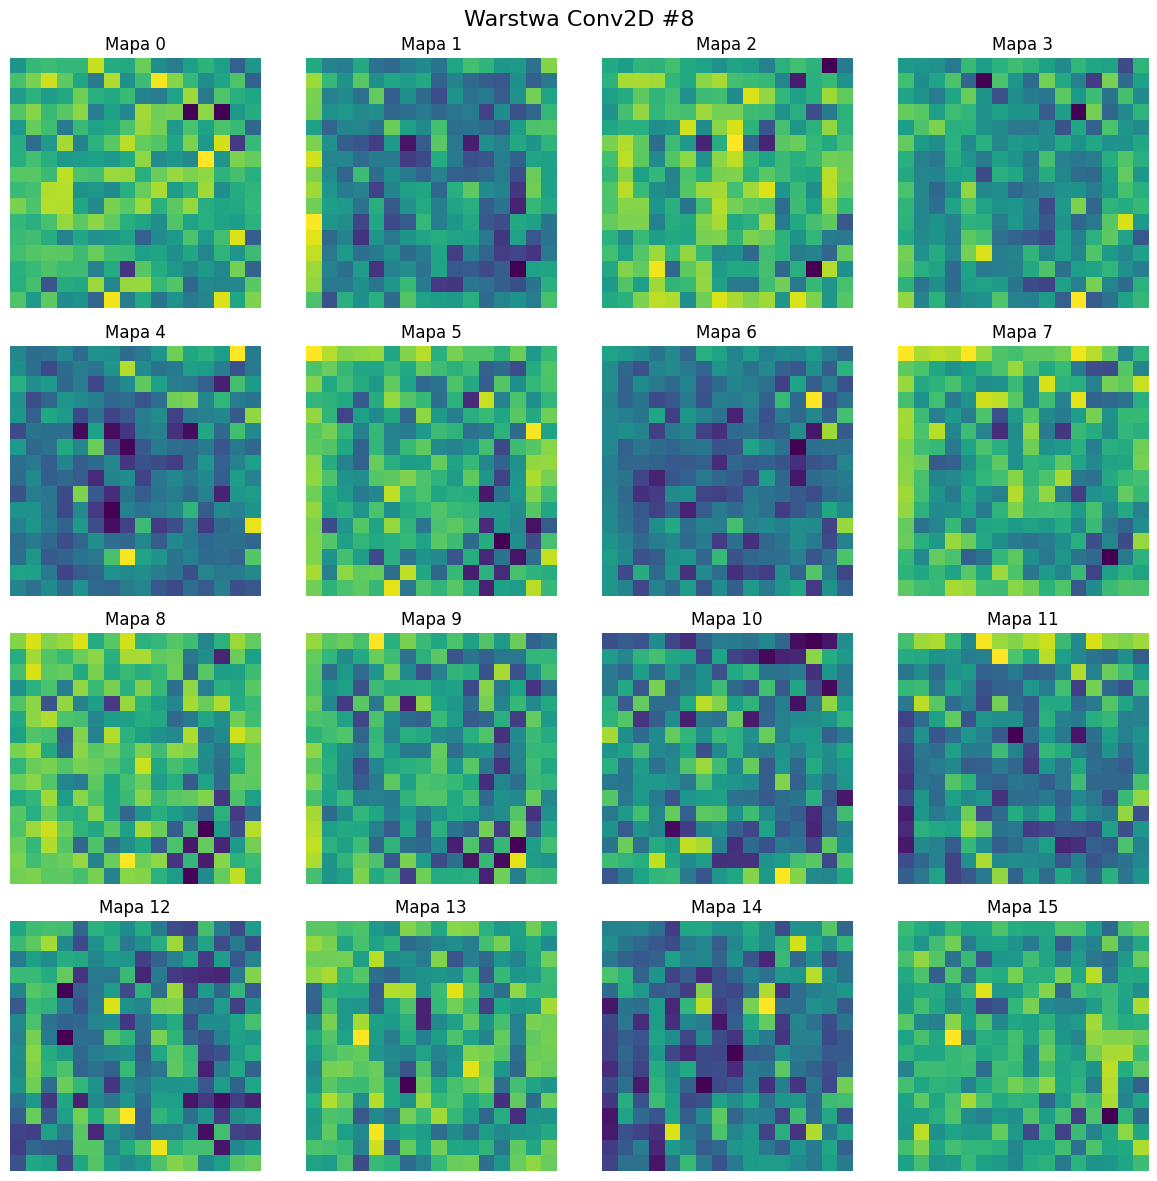

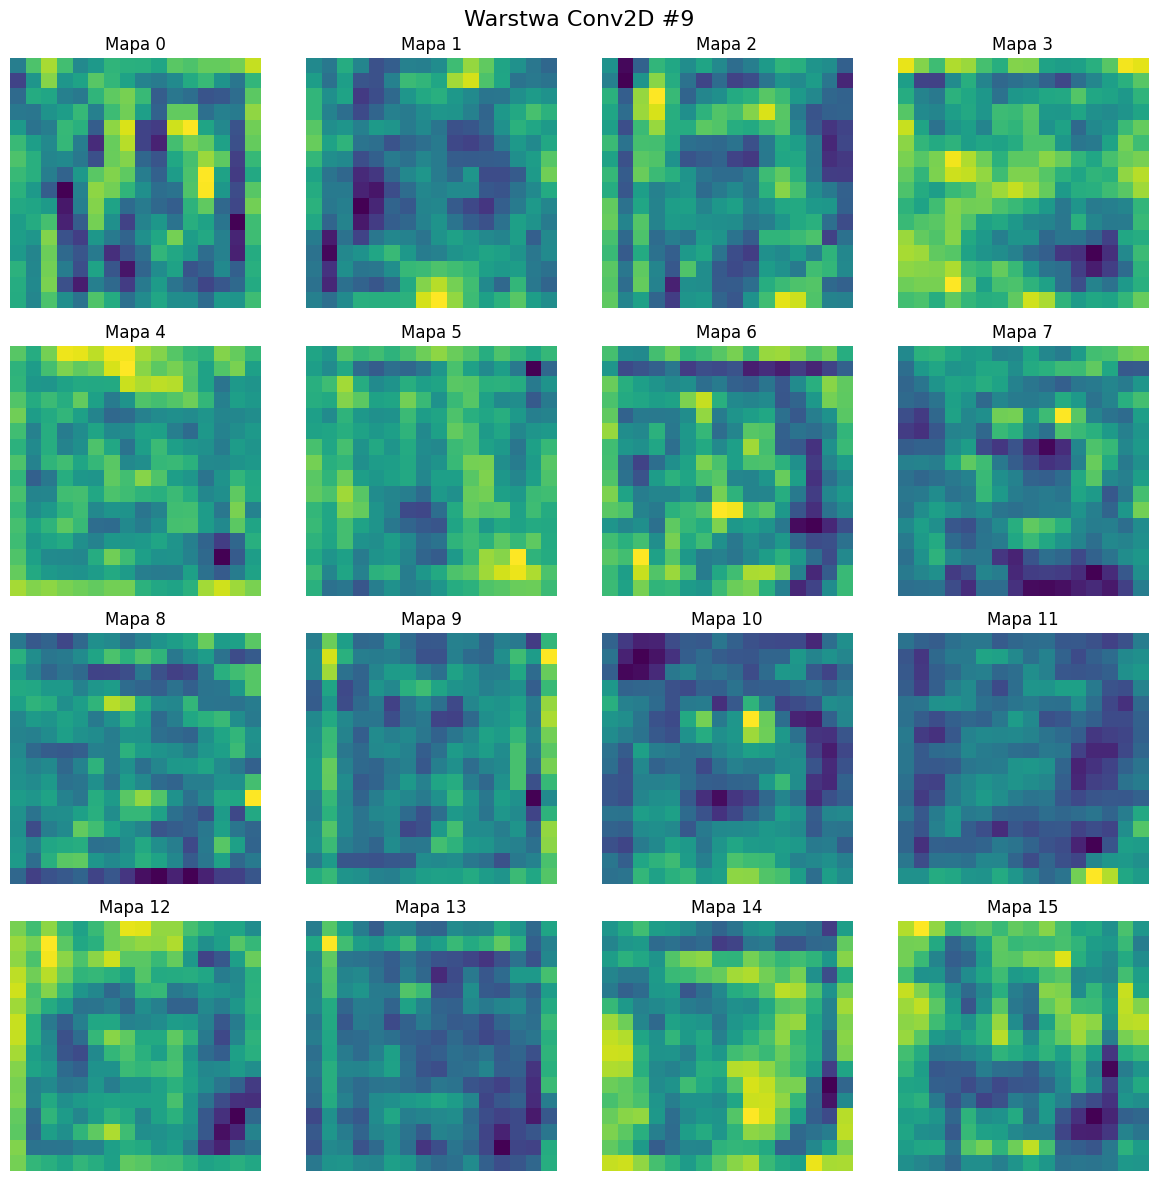

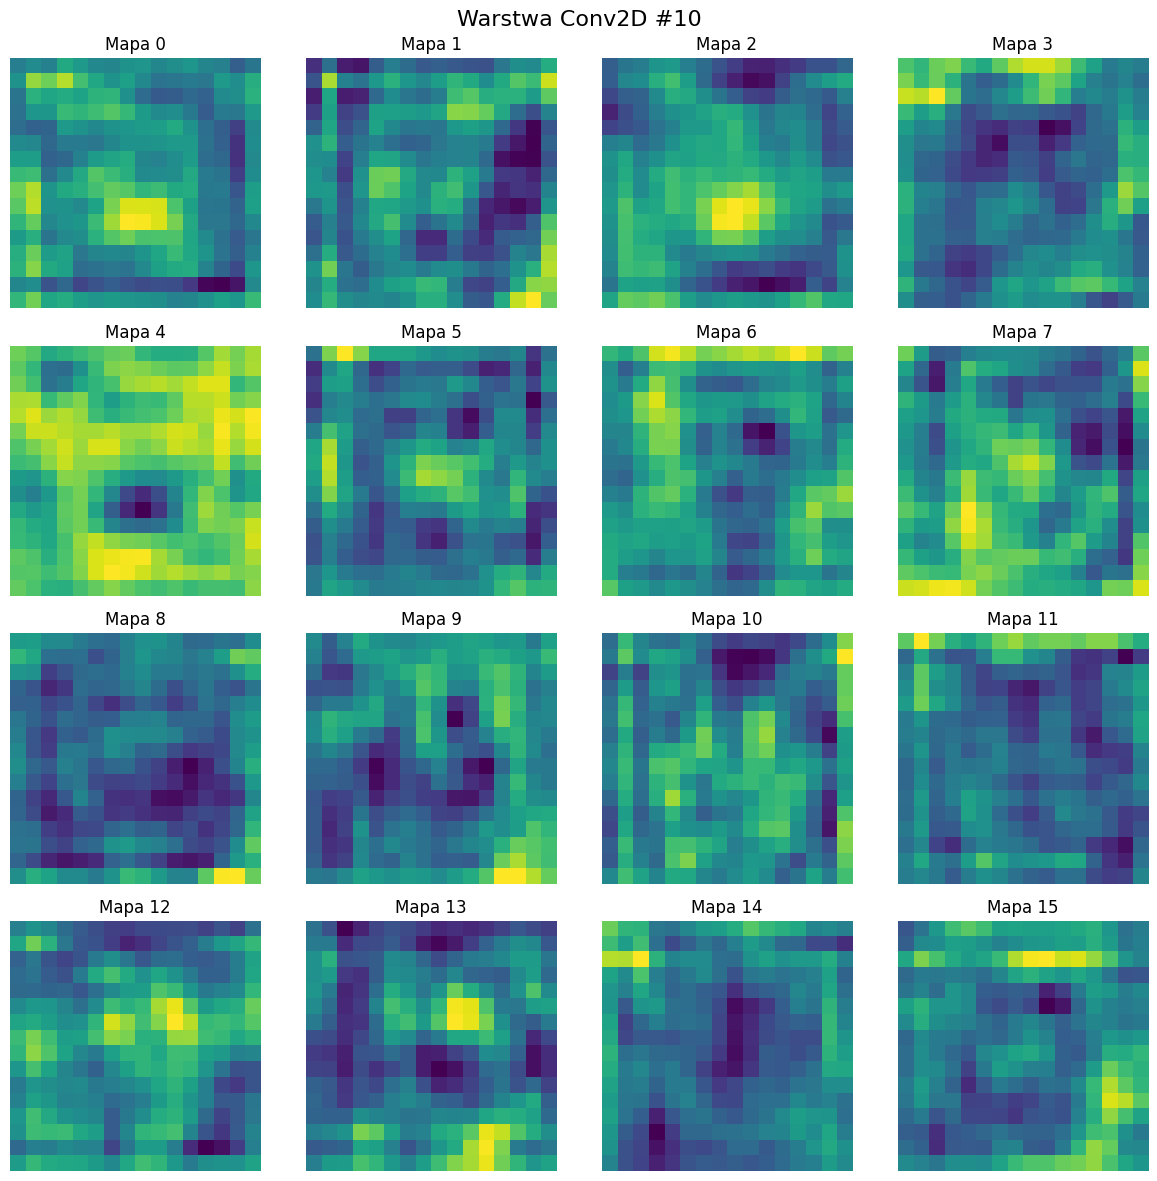

In [78]:
for i, fmap in enumerate(feature_maps[:10]):
    plot_feature_maps(fmap, max_maps=16, title=f"Warstwa Conv2D #{i+1}")

Celem zadania było zbudowanie i optymalizacja modelu konwolucyjnej sieci neuronowej do klasyfikacji obrazów ze zbioru CIFAR-100, ograniczonego do 25 losowo wybranych klas. Dane zostały odpowiednio przefiltrowane, przetasowane oraz znormalizowane.

W pierwszym etapie zastosowano prostą architekturę CNN, która osiągnęła skuteczność walidacyjną na poziomie około 58%. Następnie wprowadzono szereg ulepszeń, obejmujących zastosowanie normalizacji batchowej (BatchNormalization), regularyzacji (Dropout), augmentacji danych oraz bardziej rozbudowanej architektury konwolucyjnej.

Kolejnym krokiem było zastosowanie głębszego modelu z blokami rezydualnymi, co pozwoliło poprawić stabilność uczenia i nieznacznie zwiększyć zdolność uogólniania modelu. Ostatecznie uzyskano skuteczność walidacyjną na poziomie około 66%, przy jednoczesnym wzroście skuteczności treningowej do około 75%. Na zbiorze testowym accuracy wynioslo okolo 65%.

Analiza wyników wskazuje na umiarkowane przeuczenie modelu, co sugeruje, że dalsza poprawa jakości wymagałaby przede wszystkim lepszej regularyzacji oraz optymalizacji procesu uczenia, a nie jedynie zwiększania złożoności architektury.

Uzyskane wyniki potwierdzają, że odpowiednie połączenie architektury sieci, regularyzacji oraz augmentacji danych ma kluczowe znaczenie dla osiągnięcia dobrej jakości klasyfikacji w zadaniach rozpoznawania obrazów.